# Day 15

---


In [1]:
import grama as gr
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
DF = gr.Intention()

# Set figure options
plt.rcParams['figure.figsize'] = [6, 6] # Need square aspect ratio for gradients to appear normal
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower


## Probability-related functions

---


In [2]:
# First, define a distribution
mg_test = gr.marg_mom("norm", mean=0, sd=1)
mg_test

/Users/zach/Git/py_grama/grama/marginals.py:338: RuntimeWarning: divide by zero encountered in scalar divide


(+0) norm, {'mean': '0.000e+00', 's.d.': '1.000e+00', 'COV': inf, 'skew.': 0.0, 'kurt.': 3.0}

In [3]:
# Evaluate the probability density function
mg_test.d(0) 

0.3989422804014327

In [4]:
# Evaluate the cumulative distribution function (CDF)
mg_test.p(0)

0.5

In [5]:
# Evaluate the quantile
# mg_test.q(0)
mg_test.q(0.25)

-0.6744897501960817

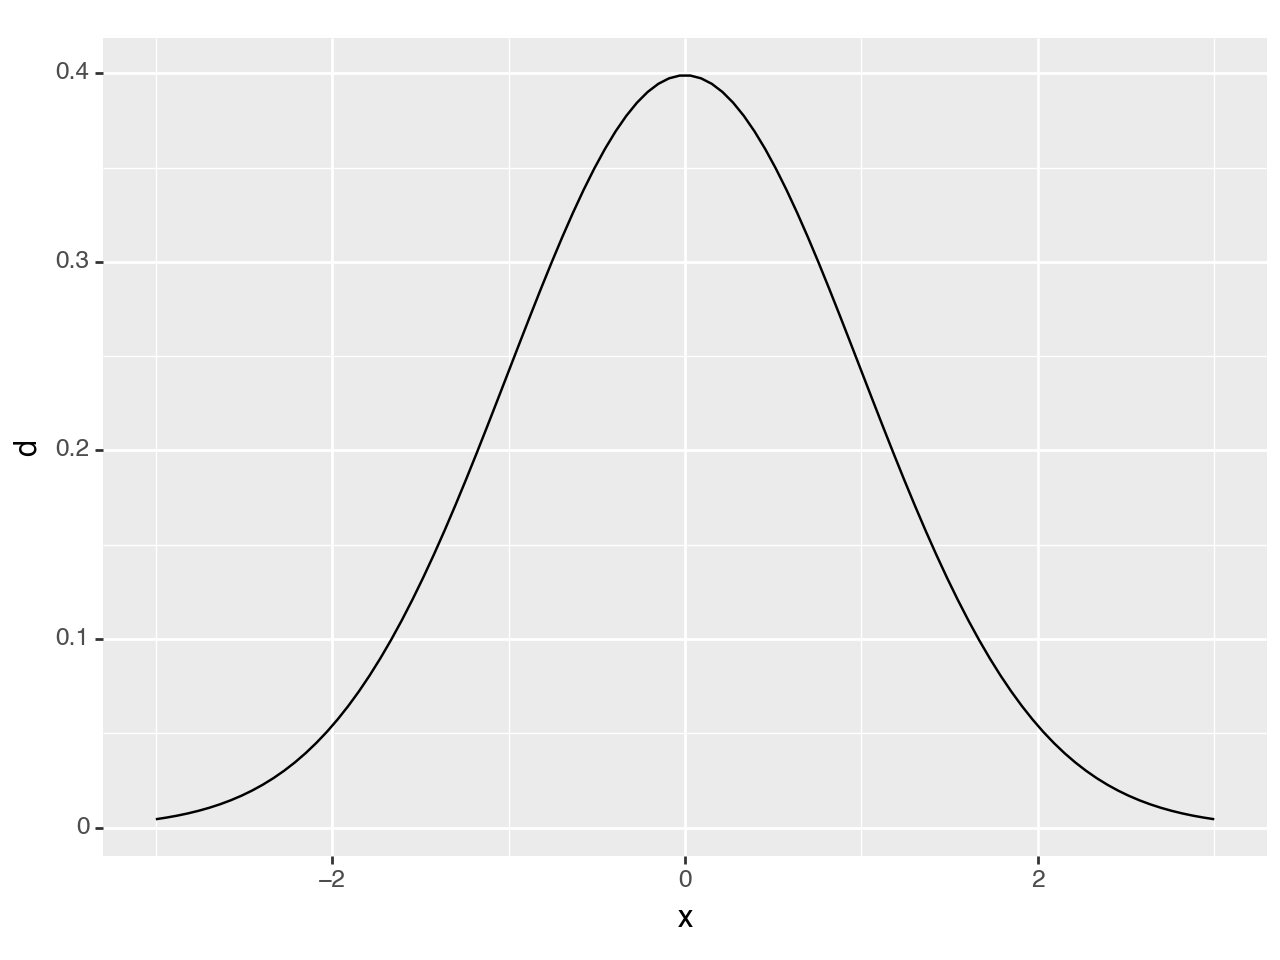

<Figure Size: (640 x 480)>

In [6]:
# Plot the PDF, for ease of understanding
(
    gr.df_make(x=gr.linspace(-3, +3, 100))
    >> gr.tf_mutate(d=mg_test.d(DF.x))
    >> gr.ggplot(gr.aes("x", "d"))
    + gr.geom_line()
)

NB We made it here on Day 15 (2026-03-24)

## Distributions and Summaries

Create distributions by name

- See Table D.6.1 of AMAU for a shortlist of distribution names
- All distributions in [scipy](https://docs.scipy.org/doc/scipy/reference/stats.html) are supported

In [7]:
# Create distributions by specifying shape and moments
mg_unif = gr.marg_mom("uniform", lo=0, up=1)
mg_unif

(+0) uniform, {'mean': '5.000e-01', 's.d.': '2.900e-01', 'COV': 0.58, 'skew.': 0.0, 'kurt.': 1.8}

In [8]:
# mg_beta = gr.marg_mom("beta", lo=0, up=1) # Not enough information
mg_beta = gr.marg_mom("beta", lo=0, up=1, mean = 0.30, sd=0.25)
mg_beta

(+0) beta, {'mean': '3.000e-01', 's.d.': '2.500e-01', 'COV': 0.83, 'skew.': 0.73, 'kurt.': 2.54}

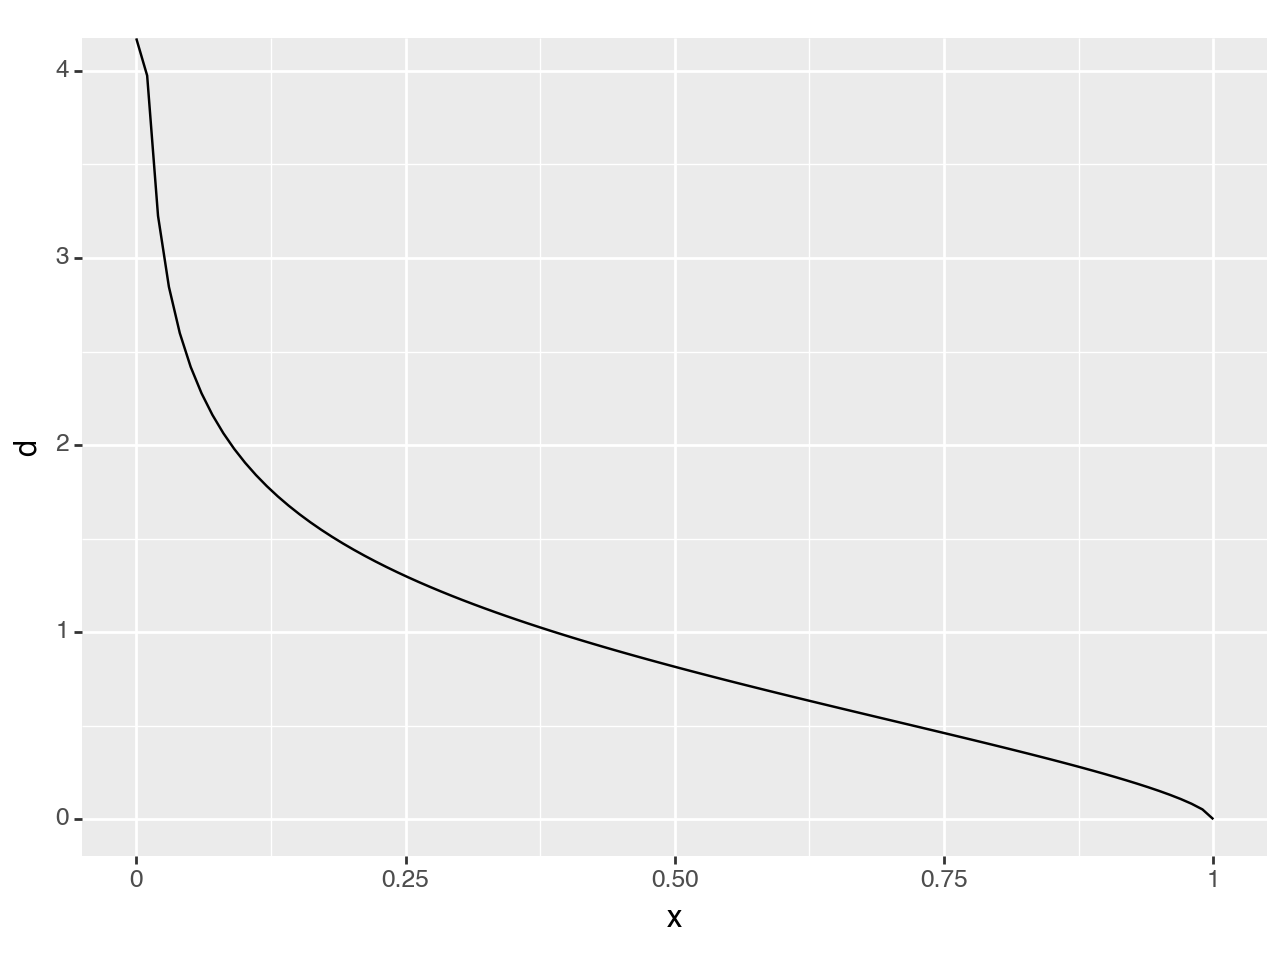

<Figure Size: (640 x 480)>

In [9]:
# Plot the PDF, for ease of understanding
(
    gr.df_make(x=gr.linspace(0, 1, 100))
    >> gr.tf_mutate(d=mg_beta.d(DF.x))
    >> gr.ggplot(gr.aes("x", "d"))
    + gr.geom_line()
)

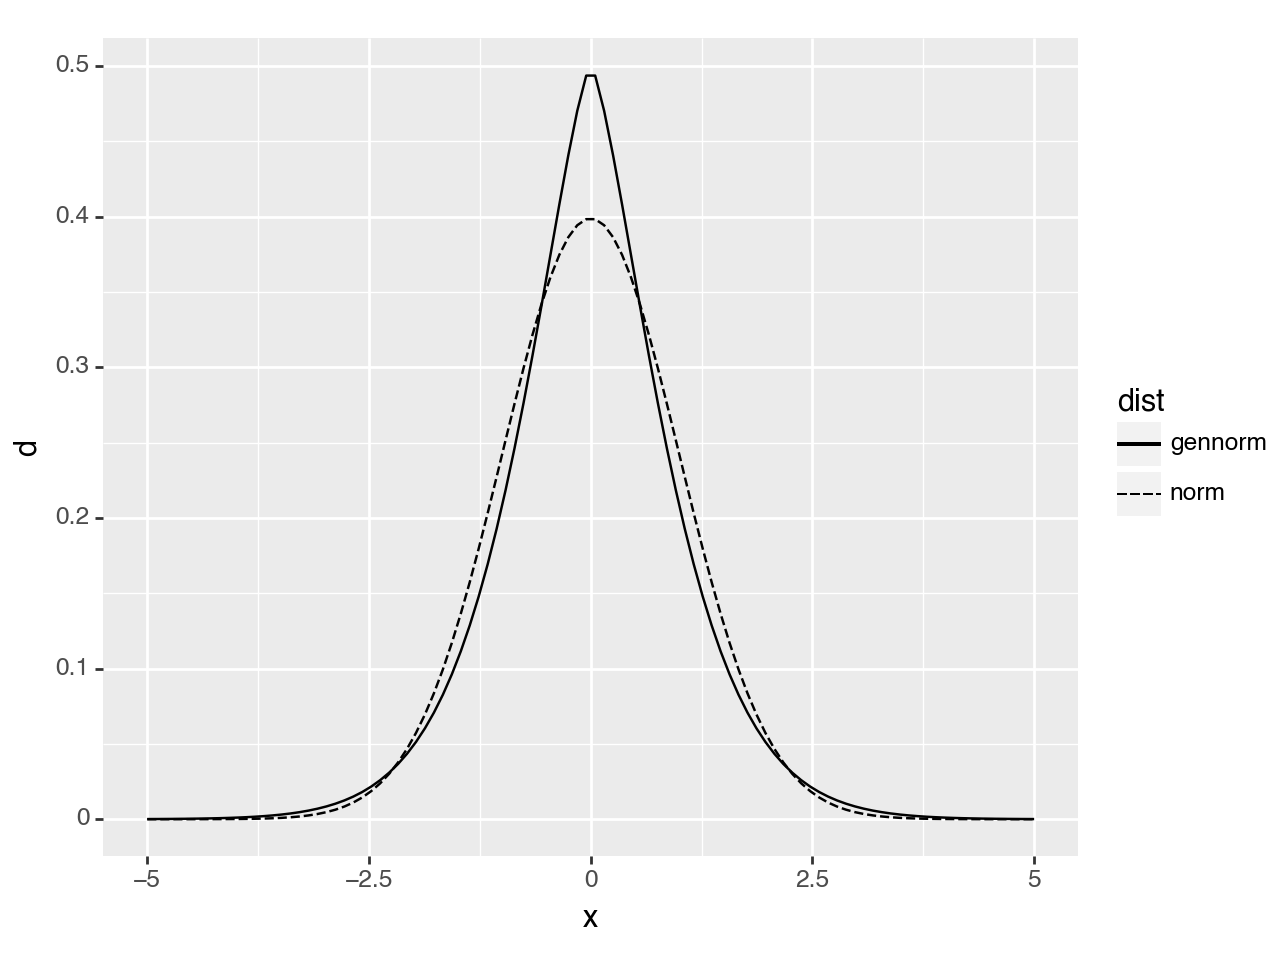

<Figure Size: (640 x 480)>

In [10]:
mg_norm = gr.marg_mom("norm", mean=0, sd=1)
mg_gnorm = gr.marg_mom("gennorm", mean=0, sd=1, kurt=4)

# Plot the PDF, for ease of understanding
(
    gr.df_make(x=gr.linspace(-5, +5, 100))
    >> gr.tf_mutate(d_norm=mg_norm.d(DF.x))
    >> gr.tf_mutate(d_gennorm=mg_gnorm.d(DF.x))
    >> gr.tf_pivot_longer(
        columns=["d_norm", "d_gennorm"],
        names_pattern=r"(d)_(\w+)",
        names_to=[".value", "dist"],
    )
    
    >> gr.ggplot(gr.aes("x", "d"))
    + gr.geom_line(gr.aes(linetype="dist"))
    # + gr.scale_y_log10()
)

## Modeling with distributions

Two approaches:

1. Fit to data
2. Fit using moments

### 1. Fit to data

If we're lucky enough to have a dataset with repeated, independent observations, we can *fit* a distribution. First, we inspect the data to get a sense of shape:

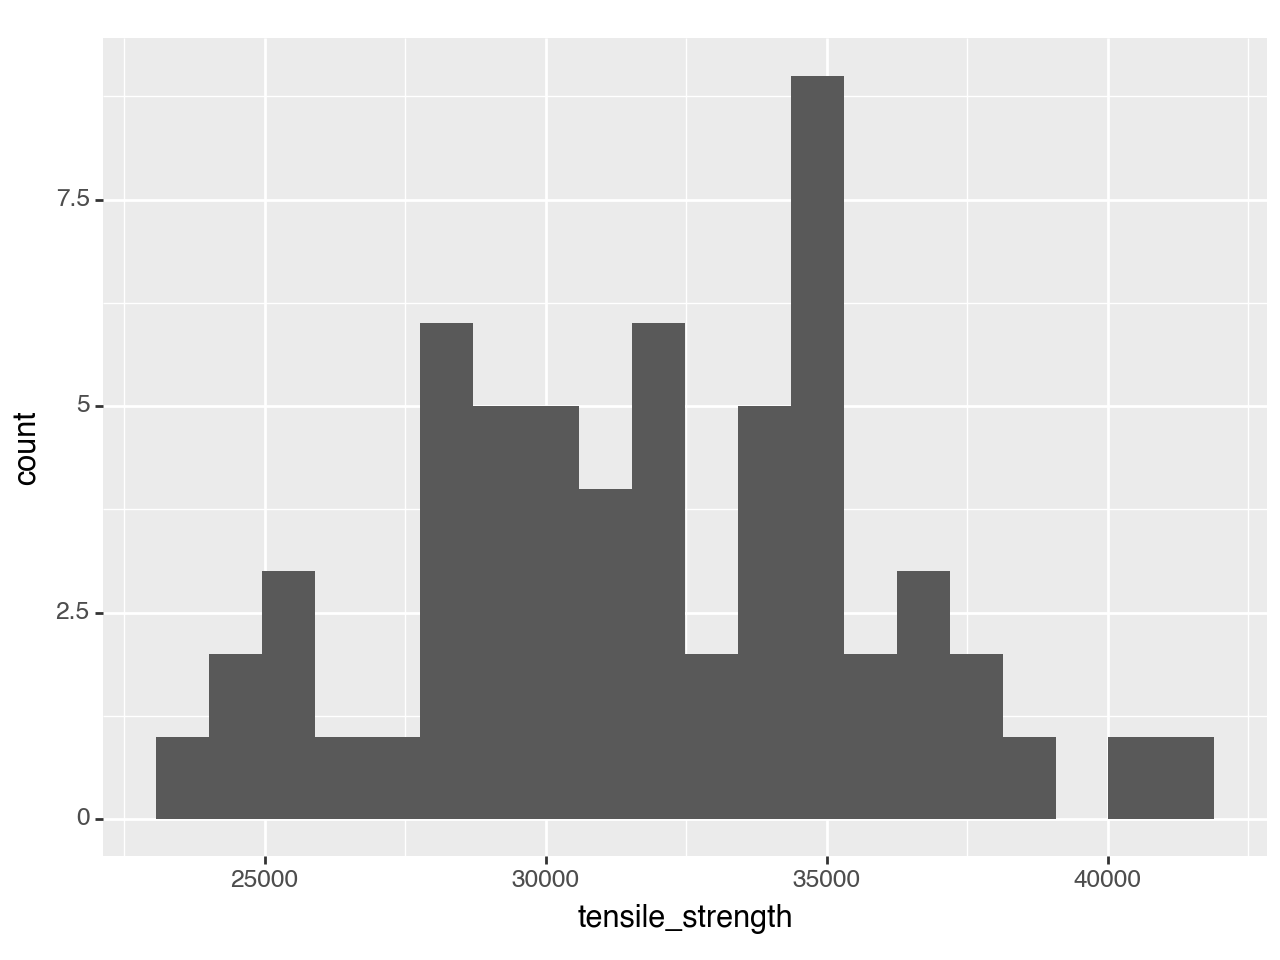

<Figure Size: (640 x 480)>

In [11]:
from grama.data import df_shewhart

(
    df_shewhart
    >> gr.ggplot(gr.aes("tensile_strength"))
    + gr.geom_histogram(bins=20)
)

We can use `gr.marg_fit()` to fit a named distribution to a dataset. We should select candidates that are physically plausible.

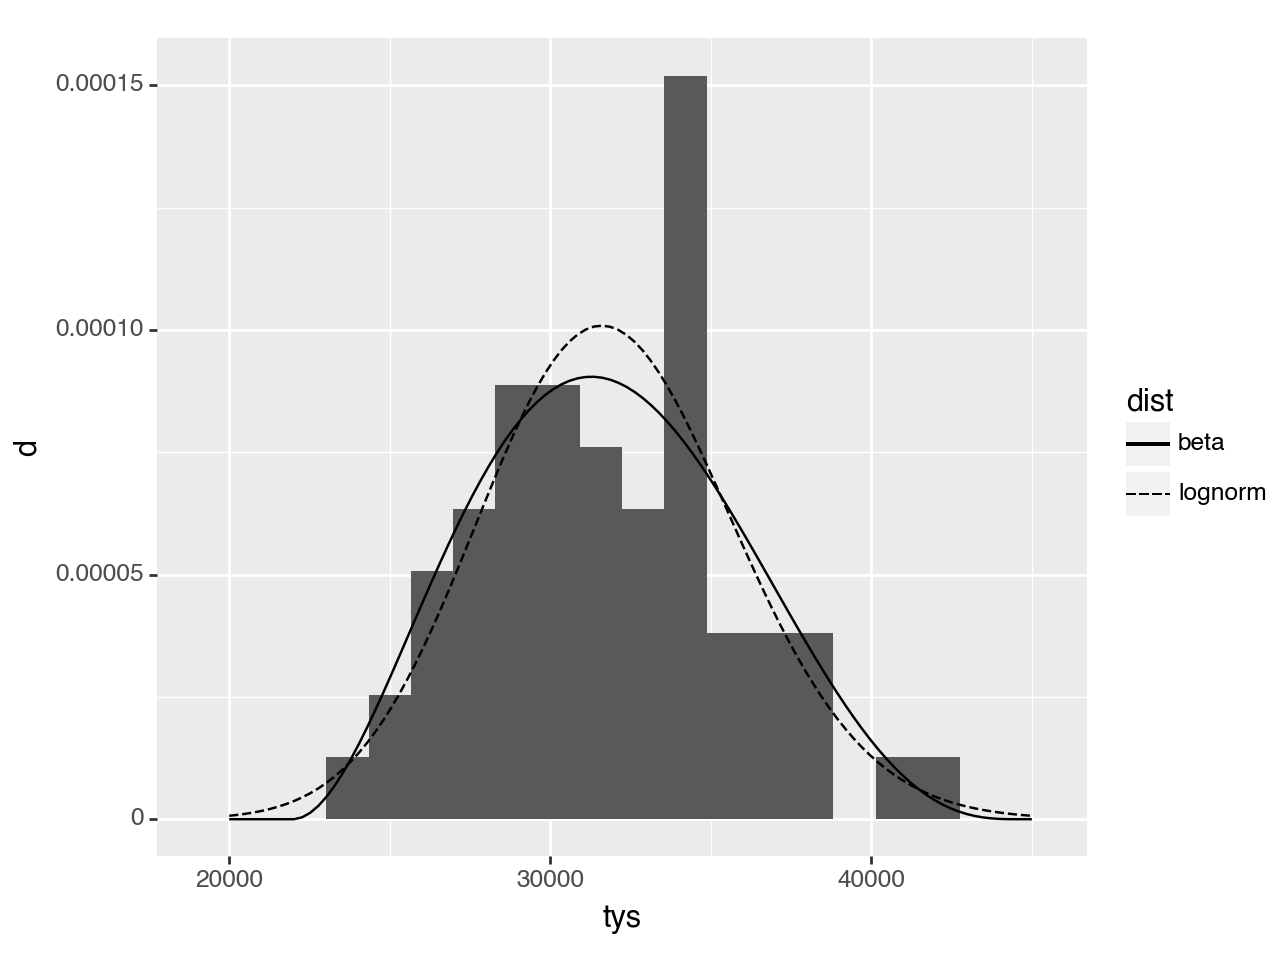

<Figure Size: (640 x 480)>

In [12]:
# Bounded values
mg_tys_beta = gr.marg_fit("beta", df_shewhart.tensile_strength)
# Bounded below
mg_tys_lognorm = gr.marg_fit("lognorm", df_shewhart.tensile_strength)

(
    gr.df_make(tys=gr.linspace(20000, 45000))
    >> gr.tf_mutate(
        d_beta=mg_tys_beta.d(DF.tys),
        d_lognorm=mg_tys_lognorm.d(DF.tys),
    )
    >> gr.tf_pivot_longer(
        columns=["d_beta", "d_lognorm"],
        names_pattern=r"(d)_(\w+)",
        names_to=[".value", "dist"],
    )
    
    >> gr.ggplot(gr.aes("tys", "d"))
    + gr.geom_histogram(
        data=df_shewhart,
        mapping=gr.aes("tensile_strength", y=gr.after_stat("density")),
        bins=20,
    )
    + gr.geom_line(gr.aes(linetype="dist"))
)

A more sensitive tool for assessing distributions is the *QQ Plot*, which we'll discuss later (see AMAU Appendix B.4):

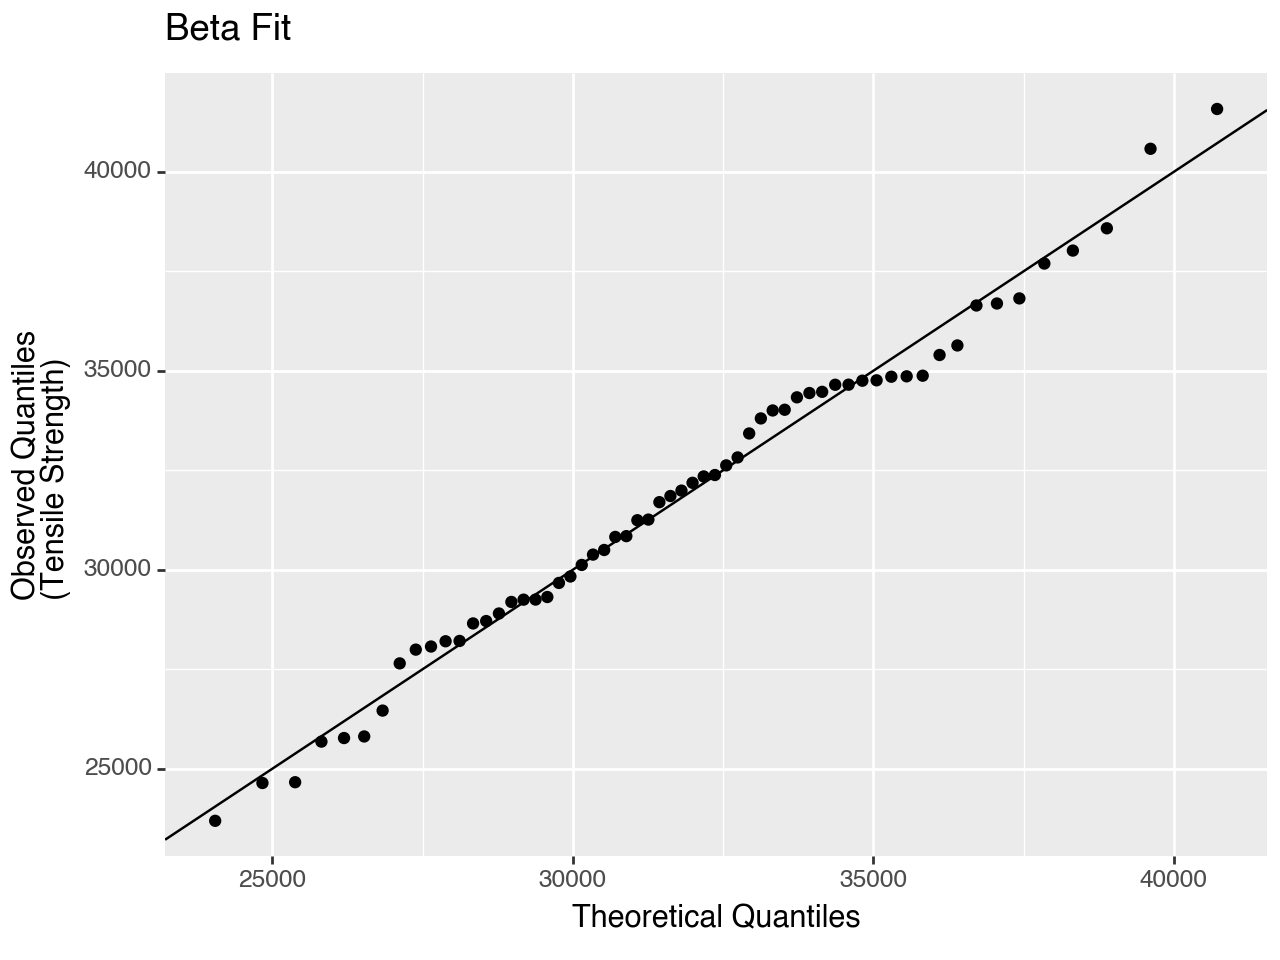

<Figure Size: (640 x 480)>

In [13]:
(
    df_shewhart
    >> gr.tf_mutate(
        q=gr.qqvals(DF.tensile_strength, "beta")
    )

    >> gr.ggplot(gr.aes("q", "tensile_strength"))
    + gr.geom_abline(slope=1, intercept=0)
    + gr.geom_point()
    + gr.labs(
        x="Theoretical Quantiles",
        y="Observed Quantiles\n(Tensile Strength)",
        title="Beta Fit",
    )
)

We can see the weird "pileup" of observations just below 35000.

### 2. Fit using moments

In many cases, we don't have data with multiple observations. We may have to settle for specifying the distribution in terms of moments.

| Material  | Property | Mean | CoV |
|-----------|----------|------|-----|
| Ti 6Al 4V | Strength (ksi) | 160 | 0.06 |

In [14]:
mg_ti64 = gr.marg_mom("norm", mean=160, cov=0.06)
mg_ti64

(+0) norm, {'mean': '1.600e+02', 's.d.': '9.600e+00', 'COV': 0.06, 'skew.': 0.0, 'kurt.': 3.0}

Problem: For other distributions, we may need higher moments

In [15]:
mg_ti64_lognorm = gr.marg_mom("lognorm", mean=160, cov=0.06)
# mg_ti64_lognorm = gr.marg_mom("lognorm", mean=160, cov=0.06, skew=0) # Not all moments are feasible
# mg_ti64_lognorm = gr.marg_mom("lognorm", mean=160, cov=0.06, skew=0.1) # ???
mg_ti64_lognorm

ValueError: Insufficient moments provided; you must provide 1 more moment(s).